# CSED 504 — A1 Computer Vision: Hello Image

Sanity-check notebook for the computer vision project.  It:

1. Verifies the environment (GPU detection, package versions)
2. Generates a small batch of synthetic images to work with
3. Builds a **Vision Transformer (ViT)** from scratch using pure PyTorch
4. Runs a forward pass and confirms the output shape is correct

If this runs end-to-end without errors, the environment is ready for A1.

---
**To use in Google Colab:**
```
!git clone https://github.com/TrueRottweiler/WashingtonCsed504.git
%cd WashingtonCsed504/src/a1-cv
```
Then run the cells below.

In [1]:
# Install required packages.  If you're running in the uw-csed504 conda environment these
# are already installed and this is a no-op.  For Colab or fresh setups it will pull them in
# automatically.
%pip install --quiet torch torchvision numpy matplotlib pillow tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
# -- 1. Path setup ---------------------------------------------------------------------------------
# Add the shared common/ utility folder to Python's search path so we can import gpu_check.py
# from there.  Inserting at index 0 means it takes precedence over any installed packages with
# the same name.  os.getcwd() returns the folder where Jupyter started — normally this
# notebook's own folder (src/a1-cv/), so '../common' resolves to src/common/.

import os, sys

_common = os.path.normpath(os.path.join(os.getcwd(), '../common'))
if os.path.isdir(_common) and _common not in sys.path:
    sys.path.insert(0, _common)

# -- 2. Device detection ---------------------------------------------------------------------------
# Transformers rely heavily on matrix multiplications.  A GPU runs those thousands of times faster
# than a CPU because it has thousands of small cores optimized for exactly this kind of parallel
# number-crunching.  We check for hardware in priority order:
#   1. CUDA  — NVIDIA GPU; the standard for ML, fastest overall
#   2. MPS   — Apple Silicon 'Metal Performance Shaders' (M1/M2/M3 Mac)
#   3. CPU   — always available; fine for this small model
# DEVICE is used throughout to move tensors to the right place.

try:
    from gpu_check import get_device, set_seed
    DEVICE = get_device()   # prints which device was found
    set_seed(42)            # lock all random seeds for reproducible results
except ImportError:
    # Fallback inline detection — runs if common/ isn't reachable
    import torch
    if torch.cuda.is_available():
        DEVICE = torch.device('cuda')
        _name  = torch.cuda.get_device_name(DEVICE)
        _gb    = torch.cuda.get_device_properties(DEVICE).total_memory / 1e9
        print(f'  Device   : CUDA — {_name} ({_gb:.1f} GB)')
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        try:
            torch.zeros(1, device='mps')
            DEVICE = torch.device('mps')
            print('  Device   : MPS — Apple Silicon GPU (unified memory)')
        except Exception:
            DEVICE = torch.device('cpu')
            print(f'  Device   : CPU ({os.cpu_count() or 1} logical cores)')
    else:
        DEVICE = torch.device('cpu')
        print(f'  Device   : CPU ({os.cpu_count() or 1} logical cores)')
    import random; import numpy as np
    random.seed(42); np.random.seed(42); torch.manual_seed(42)

  PyTorch  : 2.11.0+cu128
  CUDA     : 12.8
  Device   : cuda  [1 GPU visible - CUDA_VISIBLE_DEVICES='GPU-c9c8e67d-cae5-8bef-2e72-629c9cd326ea']
    cuda:0  NVIDIA RTX 2000 Ada Generation Laptop GPU  sm_89  8.6 GB  <- cuda:0 (primary)


In [3]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## 1. Sample Images

We work with synthetic 3×32×32 images (same resolution as CIFAR-10) so the notebook runs instantly
without any downloads.  Real data loading lives in the actual A1 notebooks.

Batch shape: (8, 3, 32, 32)  (B, C, H, W)


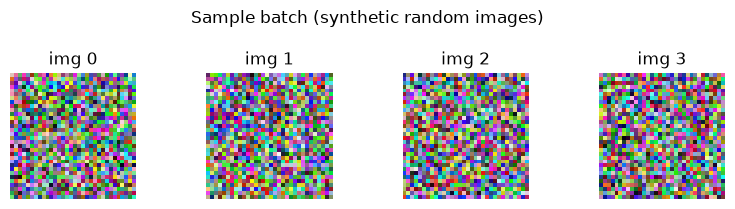

In [4]:
# Create a small batch of random RGB images.  Values are in [0, 1].  torch.rand generates
# uniform random floats — they stand in for real pixel data.
#
# Shape follows PyTorch's standard convention for image tensors: (B, C, H, W)
#   B = batch size  — how many images we process in one forward pass
#   C = channels    — 3 for RGB (red, green, blue)
#   H = height      — 32 pixels
#   W = width       — 32 pixels  (same resolution as the CIFAR-10 dataset)
# Training in batches is more efficient than one image at a time because GPUs can run all B
# images through the model simultaneously.
BATCH_SIZE  = 8
IN_CHANNELS = 3
IMG_SIZE    = 32

images = torch.rand(BATCH_SIZE, IN_CHANNELS, IMG_SIZE, IMG_SIZE)
print(f'Batch shape: {tuple(images.shape)}  (B, C, H, W)')

# -- Visualize the first four images ---------------------------------------------------------------
# matplotlib's imshow() expects the channel axis LAST: (H, W, C).  Our tensors store channels
# FIRST: (C, H, W) — PyTorch's convention.  .permute(1, 2, 0) reorders the axes:  0(C)→2  1(H)→0
# 2(W)→1.  The result is (H, W, C) which is what imshow needs.
fig, axes = plt.subplots(1, 4, figsize=(8, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].permute(1, 2, 0).numpy())
    ax.set_title(f'img {i}')
    ax.axis('off')
plt.suptitle('Sample batch (synthetic random images)', y=1.02)
plt.tight_layout()
plt.show()

## 2. Vision Transformer (ViT) from Scratch

The **Vision Transformer** treats an image as a sequence of fixed-size patches — the visual
equivalent of words in a sentence.  The architecture:

```
image (3×32×32)
  └─ PatchEmbedding      → (B, N, D)   N patches, each projected to dim D
       └─ prepend [CLS]  → (B, N+1, D)
          └─ + pos embed → (B, N+1, D)
             └─ × L TransformerBlocks → (B, N+1, D)
                └─ CLS token → Linear head → (B, num_classes)
```

Reference: *An Image is Worth 16x16 Words* (Dosovitskiy et al., 2020)

In [5]:
# Hyperparameters — ViT-Tiny scale, tuned for 32×32 images
#
# PATCH_SIZE: each image is divided into non-overlapping squares of this size.  4×4 patches on a
#   32×32 image → (32/4)² = 64 patches per image.  Smaller patches → finer spatial resolution
#   but longer sequences (slower).
#
# EMBED_DIM: dimension of each patch's learned vector representation — the 'vocabulary space'
#   for visual patches, analogous to word embeddings in NLP.  MUST be divisible by NUM_HEADS
#   so each head gets an equal-sized slice.
#
# NUM_HEADS: multi-head attention runs NUM_HEADS independent attention operations on different
#   EMBED_DIM/NUM_HEADS-dimensional subspaces.  Each head can learn to focus on a different
#   aspect (edges, color, etc.).
#
# NUM_LAYERS: depth of the transformer.  More layers → more expressive, but slower to train.
#   4 is enough to learn meaningful patterns here.
#
# MLP_DIM: hidden size of the two-layer FFN inside each transformer block.  Convention is 4×
#   EMBED_DIM; we use 2× here to keep the model light.
#
# DROPOUT: fraction of activations randomly zeroed during training.  Forces the model not to
#   rely too heavily on any single feature (regularization).  Always disabled at eval time.
PATCH_SIZE  = 4
EMBED_DIM   = 128
NUM_HEADS   = 4     # 128 / 4 = 32 dimensions per head
NUM_LAYERS  = 4
MLP_DIM     = 256   # 2× EMBED_DIM
NUM_CLASSES = 10    # CIFAR-10 has 10 classes
DROPOUT     = 0.1

In [6]:
class PatchEmbedding(nn.Module):
    """
    Split an image into non-overlapping patches and linearly project each one into the embedding
    space.  This is the ViT equivalent of a word embedding.

    A Conv2d with kernel_size == stride == patch_size is equivalent to:
      (a) slicing the image into non-overlapping patches, then
      (b) applying the same linear projection to each patch.
    One layer handles both steps, so it's clean and efficient.

    Input:  (B, C, H, W)
    Output: (B, num_patches, embed_dim)
    """

    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        assert img_size % patch_size == 0, 'Image size must be divisible by patch size'

        # How many patches does one image produce?
        # 32×32 image with 4×4 patches → (32/4)² = 64 patches
        self.num_patches = (img_size // patch_size) ** 2

        # Conv2d with kernel_size = stride = patch_size is a clean trick: the kernel slides in
        # non-overlapping steps of patch_size pixels, and each application is exactly one linear
        # projection of one patch.  This replaces a manual reshape + nn.Linear and is GPU-optimized.
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        # Step 1: apply the convolutional projection
        #   (B, C, H, W) → (B, embed_dim, H/P, W/P) — each output position is one patch
        x = self.projection(x)

        # Step 2: flatten the 2D grid of patches into a 1D sequence
        #   (B, D, H/P, W/P) → (B, D, num_patches) — flatten(2) collapses all dims from index 2 on
        x = x.flatten(2)

        # Step 3: swap dims so sequence length comes before embedding dimension
        #   (B, D, num_patches) → (B, num_patches, D) — transformers expect (Batch, Sequence, Dim)
        x = x.transpose(1, 2)
        return x

In [7]:
class TransformerBlock(nn.Module):
    """
    Standard Transformer encoder block with Pre-LayerNorm.

    Pre-LN (normalize *before* attention and FFN) trains more stably at depth than the original
    Post-LN from 'Attention is All You Need'.  The ViT paper and most modern variants use Pre-LN.

    Structure:
        x → LayerNorm → MultiHeadAttention → + residual
          → LayerNorm → FFN               → + residual
    """

    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()

        # LayerNorm rescales each token's vector to zero mean, unit variance.  This stabilizes
        # training by keeping activations in a healthy range, regardless of how deep the network is.
        self.norm1 = nn.LayerNorm(embed_dim)

        # PyTorch's built-in multi-head attention handles the Q/K/V projections, scaled dot-product,
        # masking (if needed), and output projection internally.  batch_first=True means our
        # tensors are (B, T, D) — the natural order.
        self.attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)

        # Position-wise feedforward network: a two-layer MLP applied to each token independently.
        # Attention gathers context from other tokens; the FFN transforms that combined information.
        # Together they form one complete block.  GELU (Gaussian Error Linear Unit) is a smooth
        # activation that outperforms ReLU empirically in transformer architectures.
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # -- Attention sub-layer -------------------------------------------------------------------
        # We pass the same normalized input as query, key, AND value — this is 'self-attention':
        # every token asks every other token in the same sequence 'how relevant are you to me?'
        # _ discards the attention weight matrix since we don't need it here.
        #
        # The `x + attn_out` is a RESIDUAL (skip) connection from ResNet.  It lets the gradient
        # flow straight back during training without shrinking, which is what makes very deep
        # networks trainable.
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out

        # -- FFN sub-layer -------------------------------------------------------------------------
        # Same residual pattern: normalize, transform, add back to input.
        x = x + self.ffn(self.norm2(x))
        return x

In [8]:
class VisionTransformer(nn.Module):
    """
    Vision Transformer (ViT) — image classification at toy scale.

    The [CLS] token aggregates global image information across the sequence and is used as the
    image representation for classification.  Its output after the transformer blocks is fed into
    a linear classifier head.
    """

    def __init__(self, img_size, patch_size, in_channels, embed_dim,
                 num_heads, num_layers, mlp_dim, num_classes, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches      = self.patch_embed.num_patches

        # The [CLS] token is a single learnable vector prepended to the patch sequence.  It has no
        # corresponding image region — its job is to attend to every patch over all transformer
        # layers and accumulate a global image summary.  Classification reads from this token.
        # Shape (1, 1, D): the outer 1s are batch and sequence placeholders broadcast in forward().
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Learnable position embeddings: one slot per patch + one for CLS.  Transformers treat the
        # input as an unordered SET — they have no built-in notion of which patch is top-left vs
        # bottom-right.  Adding a unique learnable vector for each position gives the model the
        # spatial information it needs.
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.drop      = nn.Dropout(dropout)

        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # Classifier: a single linear layer maps from embed_dim to num_classes.  No softmax here
        # — we return raw logits; CrossEntropyLoss applies softmax internally, which is numerically
        # more stable.
        self.head = nn.Linear(embed_dim, num_classes)

        # Truncated-normal initialization keeps initial values small and centered, preventing early
        # saturation of activations.  std=0.02 is the value used in the original ViT paper.
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)

        # 1. Turn the image into a sequence of patch embeddings
        x = self.patch_embed(x)                          # (B, N, D)

        # 2. Prepend the CLS token to every image in the batch.
        #    .expand(B, -1, -1) broadcasts (1, 1, D) → (B, 1, D) without copying memory.
        #    -1 means 'keep this dimension size unchanged'.
        cls = self.cls_token.expand(B, -1, -1)           # (B, 1, D)
        x   = torch.cat([cls, x], dim=1)                 # (B, N+1, D)

        # 3. Add position encoding (so each slot knows its spatial location), then apply dropout.
        x = self.drop(x + self.pos_embed)

        # 4. Run through all transformer blocks.  Every token (patches + CLS) attends to every
        #    other token and updates its representation.
        x = self.blocks(x)
        x = self.norm(x)

        # 5. Read out only the CLS token (index 0).  After attending to all patches through all
        #    layers, this single vector has gathered a global image summary for classification.
        cls_out = x[:, 0]                                # (B, D)
        return self.head(cls_out)                        # (B, num_classes)

    def num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

## 3. Smoke Test

Instantiate the model, move it to the detected device, and run a forward pass on the synthetic
batch.  If the output shape is `(8, 10)` and there are no errors, the whole stack is working
correctly.

In [9]:
# Build the model and move all its parameters to the detected device.
# .to(DEVICE) copies all learnable weight tensors to that device's memory (GPU VRAM or system RAM).
model = VisionTransformer(
    img_size    = IMG_SIZE,
    patch_size  = PATCH_SIZE,
    in_channels = IN_CHANNELS,
    embed_dim   = EMBED_DIM,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    mlp_dim     = MLP_DIM,
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT,
).to(DEVICE)

print(f'Model parameters : {model.num_parameters():,}')
print(f'Patches per image: {model.patch_embed.num_patches}')

# -- Forward pass ----------------------------------------------------------------------------------
# model.eval() switches off dropout (and batch norm if present).  Dropout randomly zeros activations
# DURING TRAINING to force the model to learn redundant representations (regularization).  For
# inference we want every neuron active so outputs are deterministic and fully-computed.
model.eval()

# torch.no_grad() tells PyTorch NOT to track operations for backpropagation.  This cuts memory
# usage in half and speeds up the forward pass significantly because no intermediate activations
# need to be stored for gradient computation.  Always wrap inference in no_grad().
with torch.no_grad():
    x      = images.to(DEVICE)    # move the batch to the same device as the model
    logits = model(x)              # raw class scores, one per class per image

print(f'Input  shape     : {tuple(x.shape)}')
print(f'Output shape     : {tuple(logits.shape)}  — expected (8, 10)')

# The assert is a sanity check: if the shape is wrong, the architecture has a bug.  Better to
# catch it here on a tiny batch than hours into real training.
assert logits.shape == (BATCH_SIZE, NUM_CLASSES), 'Output shape mismatch!'
print()
print('All checks passed.  Environment is ready for A1.')

Model parameters : 546,186
Patches per image: 64
Input  shape     : (8, 3, 32, 32)
Output shape     : (8, 10)  — expected (8, 10)

All checks passed.  Environment is ready for A1.
